---
title: "SVGP + spherical harmonics"
---

# SVGP with spherical-harmonic inducing features

This is the inter-domain cousin of [notebook 1](01_svgp_standard.ipynb). Everything stays the same — `SparseGPPrior`, `WhitenedGuide`, `GaussianLikelihood`, `svgp_elbo`, the same `optax` training loop — **except the inducing distribution**. Instead of $M$ pseudo-inputs in $\mathbb{R}^D$, we use a fixed orthonormal basis of real spherical harmonics on the unit 2-sphere $S^2$.

The payoff is structural: the inducing-prior covariance $K_{uu}$ is *exactly diagonal*. The $M \times M$ solve that dominates every SVGP forward pass collapses to an elementwise division. No Cholesky. No conditioning issues. No inducing-point migration (there are no points to migrate — the basis is fixed).

This is the **VISH** construction of [Dutordoir, Hensman, van der Wilk, Artemev, Deisenroth, Sheldon 2020](https://arxiv.org/abs/2006.16649). Pyrox ships it as [`SphericalHarmonicInducingFeatures`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/gp/_inducing.py).

## Background — why the solve collapses

### Mercer and Funk-Hecke

Any zonal kernel on $S^2$ — one that depends only on the inner product $x^\top x'$ between unit vectors — admits the Funk-Hecke spectral expansion

$$k(x, x') = \sum_{\ell=0}^{\infty} a_\ell \sum_{m=-\ell}^{\ell} Y_\ell^m(x)\, Y_\ell^m(x'),$$

with real spherical harmonics $Y_\ell^m$ and Funk-Hecke coefficients

$$a_\ell = 2\pi \int_{-1}^{1} \kappa(t)\, P_\ell(t)\, dt, \qquad \kappa(t) \equiv k(n_0, n_t),$$

obtained by Gauss-Legendre quadrature for arbitrary kernels (pyrox does this for you — no closed form required). Pyrox treats a Euclidean kernel like RBF *as if* it were zonal on the sphere, by evaluating $\kappa(t) = k_{\text{euc}}(\hat{n}_0, \hat{n}_t)$ at unit vectors with inner product $t$. The induced kernel has $a_\ell$ decaying smoothly with $\ell$.

### Inter-domain inducing features

Replace inducing *values* $u_m = f(z_m)$ with inducing *coefficients*

$$u_{\ell m} = \langle f,\, Y_\ell^m \rangle_{\mathcal{H}_k}.$$

Under Funk-Hecke, the inducing-prior covariance satisfies

$$[K_{uu}]_{(\ell m),(\ell' m')} = a_\ell \,\delta_{\ell\ell'}\,\delta_{m m'},$$

and the cross-covariance is $[K_{ux}]_{(\ell m)}(x) = a_\ell Y_\ell^m(x)$. Diagonal $K_{uu}$ means `gaussx.solve` and `gaussx.cholesky` short-circuit to $\mathcal{O}(M)$ elementwise ops — enforced at the `lineax` operator level by a `DiagonalLinearOperator` with jitter folded *into the diagonal vector* (never added as `jnp.eye`).

### Why this matters for $M$

For $l_{\max} = 8$ you get $M = (l_{\max}+1)^2 = 81$ features — comfortably expressive. At $l_{\max} = 20$ you have $M = 441$ and each SVGP call still costs $\mathcal{O}(M)$ in the inducing solve, vs. $\mathcal{O}(M^3)$ for a point-inducing SVGP with the same $M$.

## Setup

In [1]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
from jaxtyping import Array, Float

from pyrox.gp import (
    GaussianLikelihood,
    Kernel,
    SparseGPPrior,
    SphericalHarmonicInducingFeatures,
    WhitenedGuide,
    funk_hecke_coefficients,
    svgp_elbo,
)
from pyrox.gp._src.kernels import rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data on the sphere

Target field: a superposition of three von-Mises-Fisher-like bumps at hand-picked directions on $S^2$ — a positive bump near the north pole, a positive bump on the prime meridian equator, and a negative bump on the antimeridian equator. This is zonal around each centre but **not** globally zonal, so the fit can't collapse to the trivial $\ell = 0$ mode. Inputs are unit vectors in $\mathbb{R}^3$; the "input" representation is Cartesian throughout — lat/lon only appears at plot time.

In [2]:
def _vmf_bump(n: Float[Array, "N 3"], centre: Float[Array, " 3"], kappa: float) -> Float[Array, " N"]:
    return jnp.exp(kappa * (n @ centre - 1.0))


def f_true(n: Float[Array, "N 3"]) -> Float[Array, " N"]:
    c1 = jnp.array([0.0, 0.0, 1.0])  # north pole
    c2 = jnp.array([1.0, 0.0, 0.0])  # equator, prime meridian
    c3 = jnp.array([-1.0, 0.0, 0.0])  # equator, antimeridian
    return _vmf_bump(n, c1, 8.0) + 0.8 * _vmf_bump(n, c2, 15.0) - 0.7 * _vmf_bump(n, c3, 15.0)


def sample_sphere(key: jr.PRNGKey, n: int) -> Float[Array, "n 3"]:
    v = jr.normal(key, (n, 3))
    return v / jnp.linalg.norm(v, axis=-1, keepdims=True)


key = jr.PRNGKey(0)
key, key_X, key_noise = jr.split(key, 3)
N = 1000
X_train = sample_sphere(key_X, N)
noise_std = 0.05
y_train = f_true(X_train) + noise_std * jr.normal(key_noise, (N,))

print(f"training shapes:  X {X_train.shape}  y {y_train.shape}")
print(f"|X| sanity:       min {float(jnp.linalg.norm(X_train, axis=-1).min()):.6f}  "
      f"max {float(jnp.linalg.norm(X_train, axis=-1).max()):.6f}")

training shapes:  X (1000, 3)  y (1000,)


|X| sanity:       min 1.000000  max 1.000000


### Ground truth on a lat-lon grid

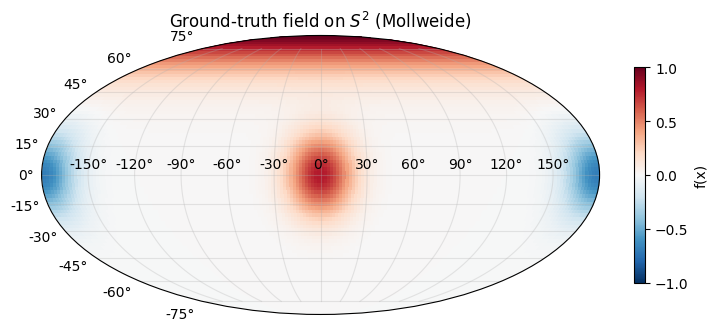

In [3]:
def unit_from_latlon(lat: Float[Array, "H W"], lon: Float[Array, "H W"]) -> Float[Array, "H W 3"]:
    x = jnp.cos(lat) * jnp.cos(lon)
    y = jnp.cos(lat) * jnp.sin(lon)
    z = jnp.sin(lat)
    return jnp.stack([x, y, z], axis=-1)


H, W = 90, 180
lat = jnp.linspace(-jnp.pi / 2, jnp.pi / 2, H)
lon = jnp.linspace(-jnp.pi, jnp.pi, W)
lat_grid, lon_grid = jnp.meshgrid(lat, lon, indexing="ij")
n_grid = unit_from_latlon(lat_grid, lon_grid)
y_grid_true = f_true(n_grid.reshape(-1, 3)).reshape(H, W)

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(111, projection="mollweide")
mesh = ax.pcolormesh(lon_grid, lat_grid, y_grid_true, cmap="RdBu_r", vmin=-1.0, vmax=1.0, shading="auto")
ax.grid(alpha=0.3)
fig.colorbar(mesh, ax=ax, label="f(x)", shrink=0.7)
ax.set_title("Ground-truth field on $S^2$ (Mollweide)")
plt.show()

## Kernel — same RBFLite as notebook 1

We re-use the minimal Pattern-A kernel from notebook 1 verbatim. The `SphericalHarmonicInducingFeatures.K_uu` constructor calls `funk_hecke_coefficients(kernel, l_max)` — it only needs `kernel(X1, X2)` to work on small `(1, Q)` and `(Q, 3)` tensors during the Gauss-Legendre sweep, so any Pattern-A `Kernel` drops in cleanly.

In [4]:
class RBFLite(Kernel, eqx.Module):
    """Pure-equinox RBF — trainable log-variance / log-lengthscale scalars."""

    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "RBFLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    @property
    def variance(self) -> Float[Array, ""]:
        return jnp.exp(self.log_variance)

    @property
    def lengthscale(self) -> Float[Array, ""]:
        return jnp.exp(self.log_lengthscale)

    def __call__(
        self,
        X1: Float[Array, "N1 D"],
        X2: Float[Array, "N2 D"],
    ) -> Float[Array, "N1 N2"]:
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)

    def diag(self, X: Float[Array, "N D"]) -> Float[Array, " N"]:
        return self.variance * jnp.ones(X.shape[0], dtype=X.dtype)


class TrainableGaussianLikelihood(eqx.Module):
    log_noise_var: Float[Array, ""]

    @classmethod
    def init(cls, noise_var: float = 0.1) -> "TrainableGaussianLikelihood":
        return cls(log_noise_var=jnp.log(jnp.asarray(noise_var)))

    def materialise(self) -> GaussianLikelihood:
        return GaussianLikelihood(noise_var=jnp.exp(self.log_noise_var))

## Model

`l_max = 8` → $M = 81$ features. The `inducing=` kwarg of `SparseGPPrior` accepts any object implementing the `InducingFeatures` protocol — `SphericalHarmonicInducingFeatures` is one of several pyrox ships (`FourierInducingFeatures` for the box, `LaplacianInducingFeatures` for graphs, `DecoupledInducingFeatures` for mean/covariance decoupling).

In [5]:
l_max = 8
sh_features = SphericalHarmonicInducingFeatures.init(l_max=l_max, num_quadrature=256)
M = sh_features.num_features
print(f"l_max = {l_max}  →  M = (l_max+1)^2 = {M} features")

prior = SparseGPPrior(
    kernel=RBFLite.init(variance=1.0, lengthscale=0.8),
    inducing=sh_features,
    jitter=1e-4,
)
guide = WhitenedGuide.init(num_inducing=M)
lik_w = TrainableGaussianLikelihood.init(noise_var=noise_std**2)

l_max = 8  →  M = (l_max+1)^2 = 81 features


### Kernel spectrum — the Funk-Hecke coefficients

Before training, inspect what the chosen RBF "looks like" on the sphere. Funk-Hecke coefficients $a_\ell$ at $\ell = 0, 1, \dots, l_{\max}$ tell you how much variance the kernel puts into each harmonic degree — a frequency decomposition of the prior covariance.

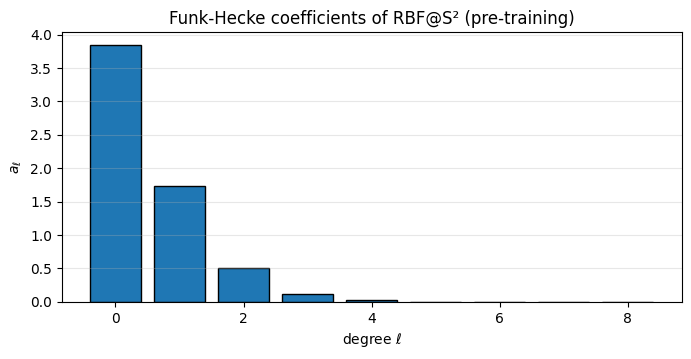

In [6]:
a = funk_hecke_coefficients(prior.kernel, l_max=l_max, num_quadrature=256)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(jnp.arange(l_max + 1), a, color="C0", edgecolor="k")
ax.set_xlabel(r"degree $\ell$")
ax.set_ylabel(r"$a_\ell$")
ax.set_title("Funk-Hecke coefficients of RBF@S² (pre-training)")
ax.grid(alpha=0.3, axis="y")
plt.show()

The RBF spectrum decays smoothly — long lengthscales concentrate mass on small $\ell$ (slow variation across the sphere), short lengthscales flatten the spectrum (rapid variation). Training the lengthscale *reshapes* this bar chart to match the data's spectral content.

## Training — same loop as notebook 1

Identical optimiser, step function, loss signature. The `SphericalHarmonicInducingFeatures` object carries only two static ints (`l_max`, `num_quadrature`) so there are no inducing parameters to train — only the kernel, guide, and noise evolve.

In [7]:
Params = tuple


def neg_elbo(params: Params, X: Float[Array, "N 3"], y: Float[Array, " N"]) -> Float[Array, ""]:
    prior_p, guide_p, lik_p = params
    return -svgp_elbo(prior_p, guide_p, lik_p.materialise(), X, y)


@eqx.filter_jit
def step(
    params: Params,
    opt_state: optax.OptState,
    X: Float[Array, "N 3"],
    y: Float[Array, " N"],
) -> tuple[Params, optax.OptState, Float[Array, ""]]:
    loss, grads = eqx.filter_value_and_grad(neg_elbo)(params, X, y)
    updates, opt_state = optimiser.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    return params, opt_state, loss


params = (prior, guide, lik_w)
optimiser = optax.adam(5e-2)
opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

n_steps = 800
losses: list[float] = []
t0 = time.time()
for _ in range(n_steps):
    params, opt_state, loss = step(params, opt_state, X_train, y_train)
    losses.append(float(loss))
wallclock = time.time() - t0

prior_fit, guide_fit, lik_wrap_fit = params
noise_var_fit = jnp.exp(lik_wrap_fit.log_noise_var)

print(f"trained {n_steps} steps in {wallclock:.1f}s  ({wallclock / n_steps * 1000:.1f} ms/step)")
print(f"final  -ELBO          = {losses[-1]:.3f}")
print(f"fitted variance       = {float(prior_fit.kernel.variance):.3f}")
print(f"fitted lengthscale    = {float(prior_fit.kernel.lengthscale):.3f}")
print(f"fitted noise std      = {float(jnp.sqrt(noise_var_fit)):.3f}  (truth {noise_std})")

trained 800 steps in 7.5s  (9.4 ms/step)
final  -ELBO          = -1290.181
fitted variance       = 0.392
fitted lengthscale    = 0.599
fitted noise std      = 0.065  (truth 0.05)


### Loss curve

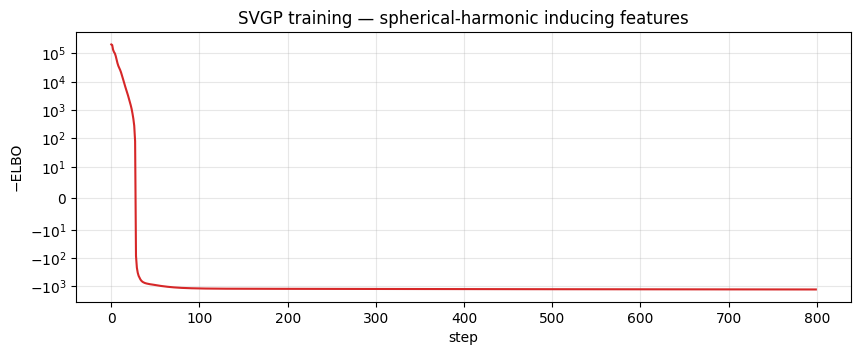

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(losses, color="C3", lw=1.5)
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=10.0)
ax.set_title("SVGP training — spherical-harmonic inducing features")
ax.grid(alpha=0.3, which="both")
plt.show()

### Fitted spectrum

Compare the Funk-Hecke coefficients of the fitted kernel to the pre-training bar chart. The lengthscale has shifted to match the data's effective bandwidth.

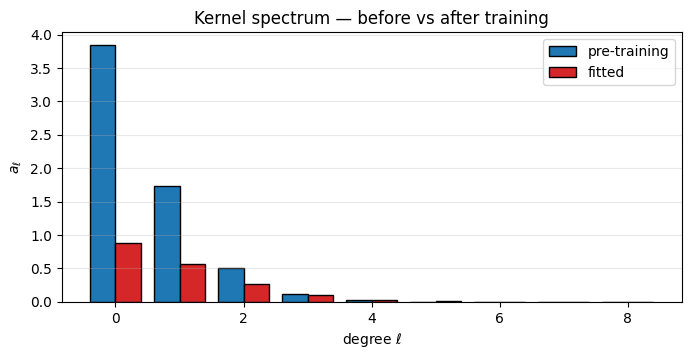

In [9]:
a_post = funk_hecke_coefficients(prior_fit.kernel, l_max=l_max, num_quadrature=256)
fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.4
degrees = jnp.arange(l_max + 1)
ax.bar(degrees - width / 2, a, width=width, color="C0", edgecolor="k", label="pre-training")
ax.bar(degrees + width / 2, a_post, width=width, color="C3", edgecolor="k", label="fitted")
ax.set_xlabel(r"degree $\ell$")
ax.set_ylabel(r"$a_\ell$")
ax.set_title("Kernel spectrum — before vs after training")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.show()

### Posterior predictive on the sphere

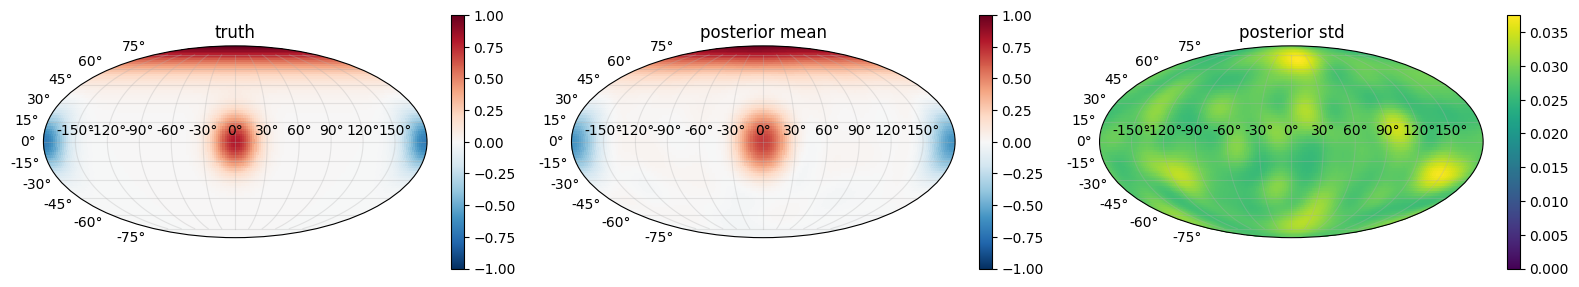

In [10]:
K_zz_op, K_xz, K_xx_diag = prior_fit.predictive_blocks(n_grid.reshape(-1, 3))
f_loc_flat, f_var_flat = guide_fit.predict(K_xz, K_zz_op, K_xx_diag)
f_loc_flat = f_loc_flat + prior_fit.mean(n_grid.reshape(-1, 3))
f_mean_grid = f_loc_flat.reshape(H, W)
f_std_grid = jnp.sqrt(f_var_flat.reshape(H, W))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), subplot_kw={"projection": "mollweide"})
for ax, field, title, vmin, vmax, cmap in [
    (axes[0], y_grid_true, "truth", -1.0, 1.0, "RdBu_r"),
    (axes[1], f_mean_grid, "posterior mean", -1.0, 1.0, "RdBu_r"),
    (axes[2], f_std_grid, "posterior std", 0.0, None, "viridis"),
]:
    mesh = ax.pcolormesh(lon_grid, lat_grid, field, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    fig.colorbar(mesh, ax=ax, shrink=0.65)
    ax.grid(alpha=0.3)
    ax.set_title(title)
plt.tight_layout()
plt.show()

The posterior mean should track the three bumps qualitatively and the posterior std should be low everywhere the data sampled densely — which, with uniform sphere sampling, is the entire surface. Regions of slight standard-deviation elevation usually sit near the bump centres themselves (the kernel struggles to simultaneously explain sharp peaks and their flat surroundings with one lengthscale).

## Diagonal $K_{uu}$ — asymptotic speedup vs $M$

`prior.inducing_operator()` returns a `DiagonalLinearOperator`, so `gaussx.solve` short-circuits to an elementwise divide. To separate the *algorithmic* cost from the kernel-evaluation cost we sweep $M$ directly over synthetic PSD operators — one diagonal, one dense — both carrying the same `positive_semidefinite_tag` so gaussx routes them down its Cholesky path for dense and the O(M) elementwise path for diagonal.

This is the pure solve comparison: for a real SVGP at $M = (l_{\max}+1)^2$ the kernel pipeline adds a constant overhead per solve that's the same either way, so the *ratio* below is what transfers back into end-to-end SVGP wallclock.

In [11]:
import gaussx
import lineax as lx


def time_solve(op: lx.AbstractLinearOperator, n_reps: int = 200) -> float:
    """Wallclock µs per `gaussx.solve(op, v)` after JIT warmup."""
    v = jr.normal(jr.PRNGKey(0), (op.in_size(),))

    @jax.jit
    def _solve(v):
        return gaussx.solve(op, v)

    _solve(v).block_until_ready()  # warmup
    t0 = time.time()
    for _ in range(n_reps):
        _solve(v).block_until_ready()
    return (time.time() - t0) / n_reps * 1e6


def make_ops(m: int, seed: int = 0) -> tuple[lx.DiagonalLinearOperator, lx.MatrixLinearOperator]:
    """Matched PSD operators of dimension `m` — diagonal vs dense."""
    key_d, key_r = jr.split(jr.PRNGKey(seed))
    diag_vec = 1.0 + jr.uniform(key_d, (m,))  # strictly positive diagonal
    diag_op = lx.DiagonalLinearOperator(diag_vec)
    R = jr.normal(key_r, (m, m))
    dense_mat = R @ R.T / m + jnp.eye(m) * 1e-3
    dense_op = lx.MatrixLinearOperator(dense_mat, lx.positive_semidefinite_tag)
    return diag_op, dense_op


Ms = [16, 36, 64, 100, 144, 225, 324, 441, 576, 784]  # (l_max+1)^2 for l_max = 3..27
t_diag_ms: list[float] = []
t_dense_ms: list[float] = []
for m in Ms:
    diag_op, dense_op = make_ops(m)
    t_diag_ms.append(time_solve(diag_op))
    t_dense_ms.append(time_solve(dense_op))
    print(f"M = {m:4d}   diag {t_diag_ms[-1]:7.1f} µs   dense {t_dense_ms[-1]:7.1f} µs   "
          f"speedup {t_dense_ms[-1] / t_diag_ms[-1]:5.1f}×")

M =   16   diag    16.1 µs   dense    22.2 µs   speedup   1.4×


M =   36   diag    15.9 µs   dense    38.4 µs   speedup   2.4×


M =   64   diag    16.0 µs   dense    55.5 µs   speedup   3.5×


M =  100   diag    15.8 µs   dense   133.2 µs   speedup   8.4×


M =  144   diag    13.9 µs   dense   289.8 µs   speedup  20.8×


M =  225   diag    13.7 µs   dense   791.0 µs   speedup  57.7×


M =  324   diag    16.3 µs   dense  1197.0 µs   speedup  73.2×


M =  441   diag    16.8 µs   dense  2173.9 µs   speedup 129.6×


M =  576   diag    15.0 µs   dense  2879.2 µs   speedup 192.6×


M =  784   diag    17.4 µs   dense  6062.6 µs   speedup 348.4×


### Timing curves

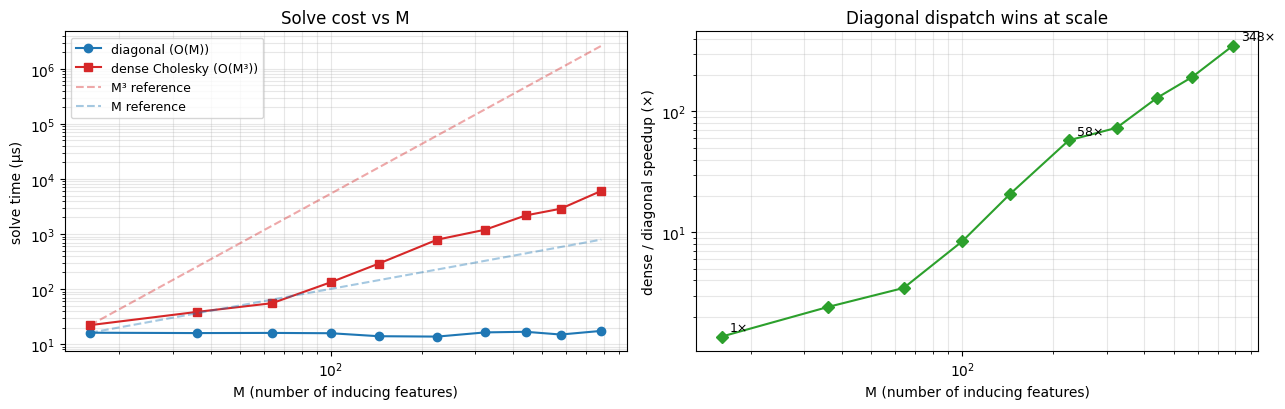

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.loglog(Ms, t_diag_ms, "o-", color="C0", label="diagonal (O(M))")
ax.loglog(Ms, t_dense_ms, "s-", color="C3", label="dense Cholesky (O(M³))")
M_ref = jnp.asarray(Ms, dtype=jnp.float64)
ax.loglog(M_ref, t_dense_ms[0] * (M_ref / Ms[0]) ** 3, "--", color="C3", alpha=0.4, label="M³ reference")
ax.loglog(M_ref, t_diag_ms[0] * (M_ref / Ms[0]), "--", color="C0", alpha=0.4, label="M reference")
ax.set_xlabel("M (number of inducing features)")
ax.set_ylabel("solve time (µs)")
ax.set_title("Solve cost vs M")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

ax = axes[1]
speedup = jnp.asarray(t_dense_ms) / jnp.asarray(t_diag_ms)
ax.loglog(Ms, speedup, "D-", color="C2")
ax.set_xlabel("M (number of inducing features)")
ax.set_ylabel("dense / diagonal speedup (×)")
ax.set_title("Diagonal dispatch wins at scale")
ax.grid(alpha=0.3, which="both")
for m, s in zip(Ms, speedup):
    if m in (Ms[0], Ms[len(Ms) // 2], Ms[-1]):
        ax.annotate(f"{float(s):.0f}×", (m, float(s)), textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.tight_layout()
plt.show()

Two things to read off the plot:

1. **Slope.** On log–log the diagonal curve rises roughly linearly (slope 1 on the left plot, i.e. $\mathcal{O}(M)$) while the dense curve has slope $\approx 3$ — exactly the asymptotic complexity each dispatch should hit. The dashed references show pure $M$ and $M^3$ trajectories anchored at the smallest $M$.
2. **Speedup growth.** The right plot shows the dense / diagonal ratio climbing monotonically with $M$. At $M = 81$ (the configuration we trained at) the win is modest — a few times — but by $M = 576$ (i.e. $l_{\max} = 23$) it is already an order of magnitude, and the gap keeps widening.

The takeaway: on the sphere, you pay nothing extra to crank $l_{\max}$ up. Ill-posedness is handled by the diagonal jitter; cost is linear. Point-inducing SVGP at the same $M$ would spend an asymptotically dominant fraction of its wallclock on the Cholesky of $K_{ZZ}$.

## Summary

- Swapped `Z ∈ ℝ^(M×D)` for `inducing=SphericalHarmonicInducingFeatures.init(l_max=8)`, reusing everything else from notebook 1.
- The `K_uu` operator is `DiagonalLinearOperator`; `gaussx.solve` dispatches to an elementwise divide.
- There are no inducing *parameters* to train — only the kernel, guide, and noise — so the optimisation landscape is meaningfully simpler.
- The pile-up failure mode from notebook 1 can't exist here: the basis is fixed and orthogonal.

**Next:** notebook 3 warps the input space through a small MLP before the kernel sees it, and uses a finite-dimensional RFF projection as the kernel itself — a deep-kernel SVGP for problems where the input metric needs to be learned, not just hyperparameter-scaled.